In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv ("C:/Users/Tharunikavaani/Downloads/Telco_customer_churn.xlsx/Telco_customer_churn.csv")

In [45]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [47]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [49]:
df.shape

(7043, 33)

In [53]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [55]:
df['Churn Reason'] = df['Churn Reason'].fillna('no churn')

In [57]:
df.isnull().sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

In [61]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [67]:
df['Churn Label'].value_counts(normalize = True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [80]:
df.duplicated().sum()

0

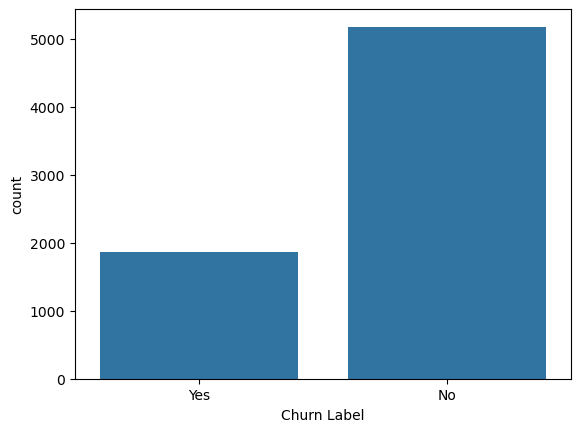

In [84]:
sns.countplot(x = 'Churn Label', data =df)
plt.show()

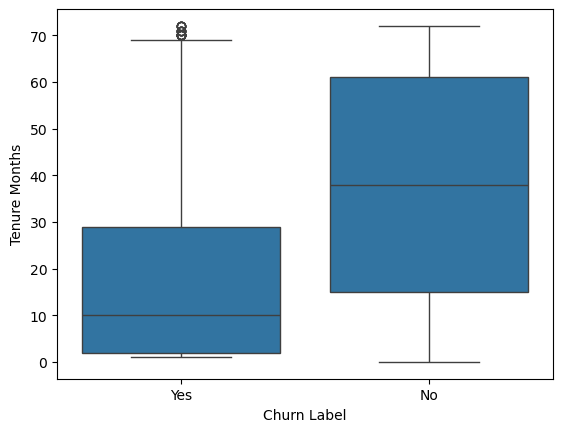

In [96]:

sns.boxplot(data = df , x = 'Churn Label', y = 'Tenure Months')
plt.show()

In [100]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [106]:
pd.crosstab(df['Contract'], df['Churn Label'])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


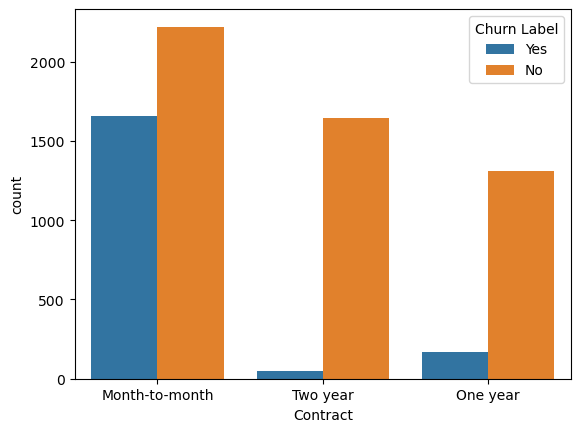

In [114]:
sns.countplot(data = df , x = 'Contract' , hue = 'Churn Label')
plt.show()

In [117]:
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [121]:
df.groupby ('Churn Label')['Monthly Charges'].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

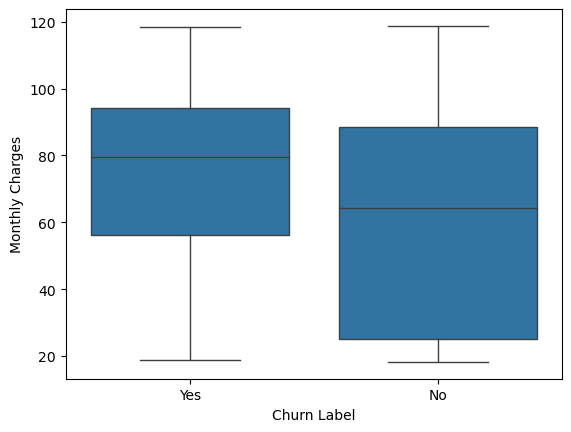

In [128]:
sns.boxplot(x = 'Churn Label' , y = 'Monthly Charges', data = df)
plt.show()

In [136]:
df['Tech Support'].value_counts()

Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [144]:
pd.crosstab(df['Tech Support'],df['Churn Label'])

Churn Label,No,Yes
Tech Support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


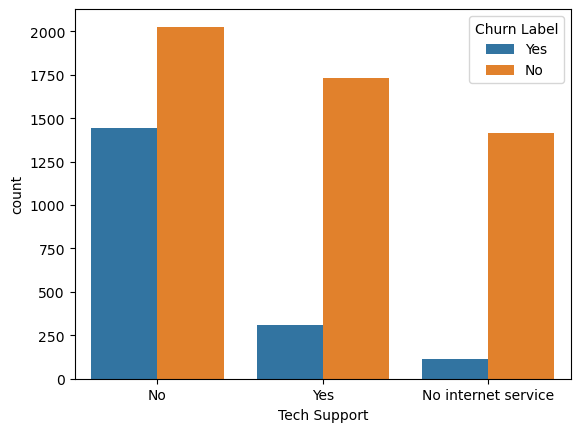

In [154]:
sns.countplot(data = df ,  x = 'Tech Support' , hue = 'Churn Label')
plt.show()

In [157]:
df['Payment Method'].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [161]:
pd.crosstab(df['Payment Method'], df['Churn Label'])

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


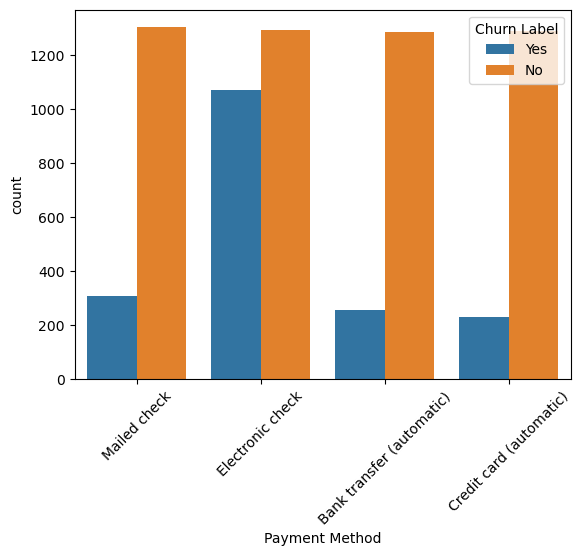

In [168]:
sns.countplot(data= df , x = 'Payment Method', hue = 'Churn Label')
plt.xticks(rotation = 45)
plt.show()

In [172]:
df['Churn Reason'].value_counts()

Churn Reason
no churn                                     5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Lack of affordable download/upload speed       44
Long distance charges                          44
Limited range of services                      44
Poor expertise of phone support                20
Poor expertise of online support     

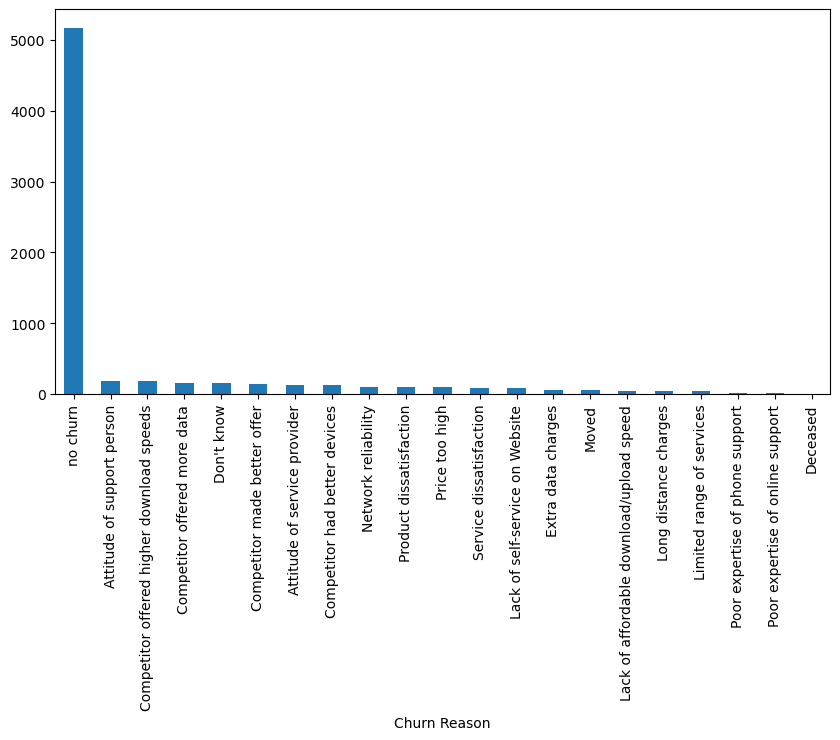

In [176]:
df['Churn Reason'].value_counts().plot(kind = 'bar',figsize=(10,5))
plt.show()

In [182]:
df['Churn Label'] = df['Churn Label'].map({'Yes':1 , 'No': 0})

In [204]:
df['Churn Label'].tail(10)

7033    0
7034    0
7035    0
7036    0
7037    0
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Label, dtype: int64

In [ ]:
df = df.drop(['CustomerID','Lat Long','Zip Code','Churn Reason'], axis=1)

In [208]:
df.head()

,Count,Country,State,City,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,United States,California,Los Angeles,33.964131,-118.272783,Male,No,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,86,3239
1,1,United States,California,Los Angeles,34.059281,-118.307420,Female,No,No,Yes,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,67,2701
2,1,United States,California,Los Angeles,34.048013,-118.293953,Female,No,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,1,86,5372
3,1,United States,California,Los Angeles,34.062125,-118.315709,Female,No,Yes,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,1,84,5003
4,1,United States,California,Los Angeles,34.039224,-118.266293,Male,No,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,1,89,5340


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Latitude           7043 non-null   float64
 5   Longitude          7043 non-null   float64
 6   Gender             7043 non-null   object 
 7   Senior Citizen     7043 non-null   object 
 8   Partner            7043 non-null   object 
 9   Dependents         7043 non-null   object 
 10  Tenure Months      7043 non-null   int64  
 11  Phone Service      7043 non-null   object 
 12  Multiple Lines     7043 non-null   object 
 13  Internet Service   7043 non-null   object 
 14  Online Security    7043 non-null   object 
 15  Online Backup      7043 non-null   object 
 16  Device Protection  7043 

In [218]:
df = pd.get_dummies(df, drop_first=True)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 7694 entries, Count to Total Charges_999.9
dtypes: bool(7685), float64(3), int64(6)
memory usage: 52.1 MB


In [289]:
X = df.drop(['Churn Label', 'Churn Value'],  axis = 1)
y = df['Churn Label']

In [291]:
from sklearn.model_selection import train_test_split

In [293]:
X_train,X_test,y_train,y_test = train_test_split (X,y,test_size = 0.2, random_state = 42)

In [295]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

C:\Users\Tharunikavaani\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [297]:
y_pred = model.predict(X_test)

In [299]:
from sklearn.metrics import accuracy_score

In [301]:
accuracy_score(y_test,y_pred)

0.907735982966643

In [303]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values(ascending=False)

Partner_Yes                               0.640719
City_Sacramento                           0.444681
City_San Dimas                            0.436005
Device Protection_Yes                     0.399650
Multiple Lines_No phone service           0.327281
                                            ...   
Payment Method_Credit card (automatic)   -0.378989
Phone Service_Yes                        -0.411288
Contract_One year                        -0.605075
Contract_Two year                        -1.791309
Dependents_Yes                           -1.991586
Length: 7692, dtype: float64

In [309]:
print(X.shape)
print(y.shape)

print(X_train.shape)
print(X_test.shape)

print('Churn in X?', 'Churn' in X.columns)

(7043, 7692)
(7043,)
(5634, 7692)
(1409, 7692)
Churn in X? False


In [307]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[941,  68],
       [ 62, 338]], dtype=int64)